In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pysonogen
import pysonogen.transducers as transducers
from PyField import PyField


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# PyField Simulations for IdV

## 1. Model experimental validation

A linear array probe with 128 elements with 110 $\mu m$ pitch, an elevation focus of 8 mm, and a center frequency of 15 MHz was calibrated using the Acertara Acoustic Measurement System (AMS). This system combines hardware and software for characterizing acoustic energy from diagnostic and therapeutic ultrasound devices, and includes a water treatment unit for degassing and filtration. A calibrated hydrophone (Onda HGL-0085, SN: 2852) with an integral preamplifier (AG-2010, SN: 1403) was mounted on a 3D motorized positioning system. The hydrophone output was recorded using a Tektronix MDO3012B oscilloscope.

The probe was driven by a Verasonics research ultrasound system to generate a focused sequence. To characterize the lateral and elevational field distribution, ten XY scans were acquired at depths of 4.5, 5.5, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.5, and 11.5 mm. To capture the axial pressure distribution, a Z-scan was performed along the central axis (x, y = 0, 0) from 4.5 to 11.5 mm with a step size of 0.01 mm, from which the peak intensity integral (PII) was extracted. By combining interpolation of the XY scans with the axial profile, a high-resolution 3D pressure field was reconstructed and later compared with simulation results.


### 1.1. Import experimental data

In [11]:
folder = 'Data_exp/'
name_exp_data = 'calibration_data_FD1_FD15_FD2.npz'
path_exp_data = folder + name_exp_data
Exp_data = np.load(path_exp_data, allow_pickle=True)
data = Exp_data['processed_data'].item()
print(data.keys())
depth_correction_mm = 0.5
real_x1, real_y1, real_z1, real_FD1 = data['x1'], data['y1'], data['z1'] - depth_correction_mm, data['FD1']
real_x15, real_y15, real_z15, real_FD15 = data['x15'], data['y15'], data['z15'] - depth_correction_mm, data['FD15']
real_x2, real_y2, real_z2, real_FD2 = data['x2'], data['y2'], data['z2'] - depth_correction_mm, data['FD2']

dict_keys(['FD1', 'x1', 'y1', 'z1', 'FD15', 'x15', 'y15', 'z15', 'FD2', 'x2', 'y2', 'z2'])


### 1.2. Perform simulations

Preparation of data for simulation

LinearArrayTransducer initialized in 0.0105 seconds.


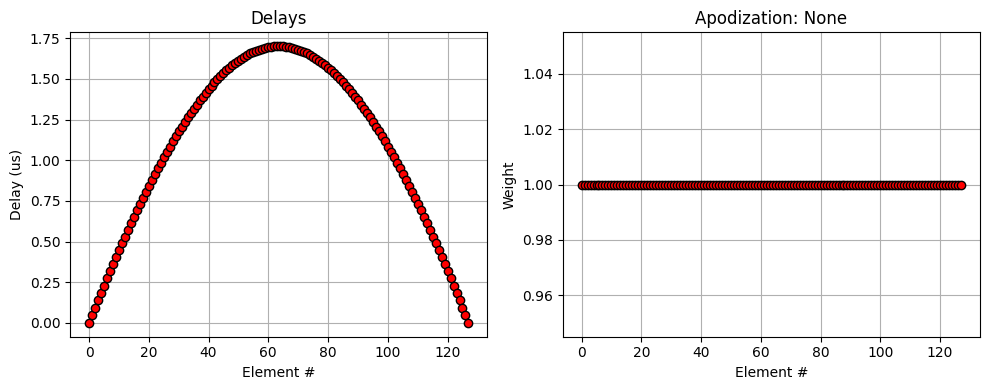

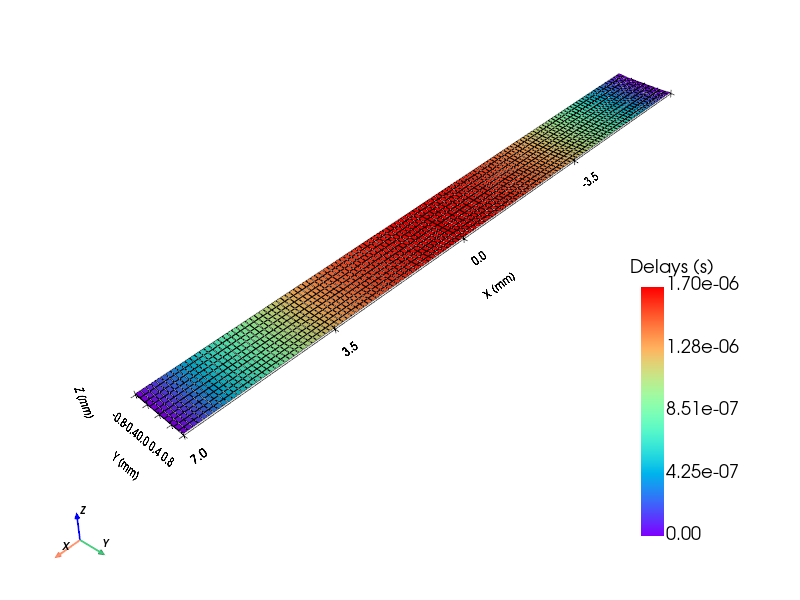

In [12]:
focus_mm = np.array([0, 0, 8])
method = 'sdi'

domino = transducers.Domino()
delays = domino.compute_delays(focus_mm=focus_mm)
domino.plot_delays_apodization()
domino.show(notebook=True, jupyter_backend='static', scalars = 'Delays')
 
field_points_FD1 = np.meshgrid(real_x1, real_y1, real_z1)
field_points_FD1 = np.array(field_points_FD1).T.reshape(-1, 3)

field_points_FD15 = np.meshgrid(real_x15, real_y15, real_z15)
field_points_FD15 = np.array(field_points_FD15).T.reshape(-1, 3)    

field_points_FD2 = np.meshgrid(real_x2, real_y2, real_z2)
field_points_FD2 = np.array(field_points_FD2).T.reshape(-1, 3)


Simulation with F/D = 1 :

In [13]:
FoverD = 1
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
simu_x1, simu_y1, simu_z1, pressure_FD1 = domino_field(field_points_FD1, method = method)


Computing SIR for 1820000 points and 1280 patches...
Computed time grid from 2.82 us to 10.65 us, with 1566 samples in 0.97 seconds.
Transducer SIR computed in 6.96 seconds...
Pressure computed from SIR in 11.33 seconds...
Pressure field computed in 25.24 seconds...


Simulation with F/D = 1.5 :

In [14]:
FoverD = 1.5
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
simu_x15, simu_y15, simu_z15, pressure_FD15 = domino_field(field_points_FD15, method = method)

Computing SIR for 2184000 points and 1280 patches...
Computed time grid from 2.82 us to 10.65 us, with 1566 samples in 1.50 seconds.
Transducer SIR computed in 7.50 seconds...
Pressure computed from SIR in 13.42 seconds...
Pressure field computed in 30.54 seconds...


Simulation with F/D = 2 :

In [15]:
FoverD = 2
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
simu_x2, simu_y2, simu_z2, pressure_FD2 = domino_field(field_points_FD2, method = method)

Computing SIR for 1820000 points and 1280 patches...
Computed time grid from 2.82 us to 10.65 us, with 1566 samples in 1.49 seconds.
Transducer SIR computed in 6.14 seconds...
Pressure computed from SIR in 10.93 seconds...
Pressure field computed in 24.97 seconds...


Normalize the simulation and rescale them with the maximum value measured during calibration.

In [16]:
# Normalize
pressure_FD1 /= np.max(np.abs(pressure_FD1))
pressure_FD15 /= np.max(np.abs(pressure_FD15))
pressure_FD2 /= np.max(np.abs(pressure_FD2))

# Convert to PII
simu_FD1 = np.max(real_FD1)*pressure_FD1**2
simu_FD15 = np.max(real_FD15)*pressure_FD15**2
simu_FD2 = np.max(real_FD2)*pressure_FD2**2

### 1.3. 3D Visualization of pressure fields

In [17]:
import pysonogen.functions.plotting_pyvista as pv_plotting
import pyvista as pv

def set_custom_style(plotter):
    cube_actor =plotter.show_bounds(
            grid = 'back', color = 'black', font_size = 12,
            location = 'outer',
            n_xlabels =3 , n_ylabels=5, n_zlabels=13-5,
            xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)",
            )
    # turn on outer gridlines and inner gridlines if you want them
    cube_actor.DrawXGridlinesOn()
    cube_actor.DrawYGridlinesOn()
    cube_actor.DrawZGridlinesOn()

    # set gridline colors to white (RGB in 0..1)
    cube_actor.GetXAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)
    cube_actor.GetYAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)
    cube_actor.GetZAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)

    # (optional) tweak gridline width
    cube_actor.GetXAxesGridlinesProperty().SetLineWidth(2.0)
    cube_actor.GetYAxesGridlinesProperty().SetLineWidth(2.0)
    cube_actor.GetZAxesGridlinesProperty().SetLineWidth(2.0)

    plotter.camera_position = [(-11.790359626834173, -11.502976928133164, 4.9699041703133755),
    (0.0, 0.0, 8.0),
    (0.12778591723122387, 0.12809234170411485, -0.9834953540073949)]  # Set the camera position
    plotter.camera.up = (0, 0, -1)

def plot_volume(x,y,z, PII, *, notebook = True, jupyter_backend = 'static', image_name = None, off_screen = False, save_screenshot = False):
    # if image_name is None:
    window_size = (420,720)

    if image_name is not None:
        save_screenshot = True
        off_screen = True
    else:
        save_screenshot = False

    pv.global_theme.anti_aliasing = 'ssaa' 
    pressure_mesh = pv_plotting.create_vol_mesh(x, y, z, PII, scalars='Pressure')
    box = pressure_mesh.bounding_box()

    plotter = pv.Plotter(title='FD1 Real Data', notebook = notebook, window_size = window_size, off_screen= off_screen)
    _ = plotter.add_mesh(box,opacity=0.2, color='#b0b0b0')

    plotter = pv_plotting.add_pressure_vol(pressure_mesh, plotter=plotter, title = 'PII₀ (μJ/cm²)')

    set_custom_style(plotter)

    if save_screenshot:
        plotter.screenshot(image_name)

    plotter.show(jupyter_backend=jupyter_backend)



Plotting F/D = 1 : real and simulated


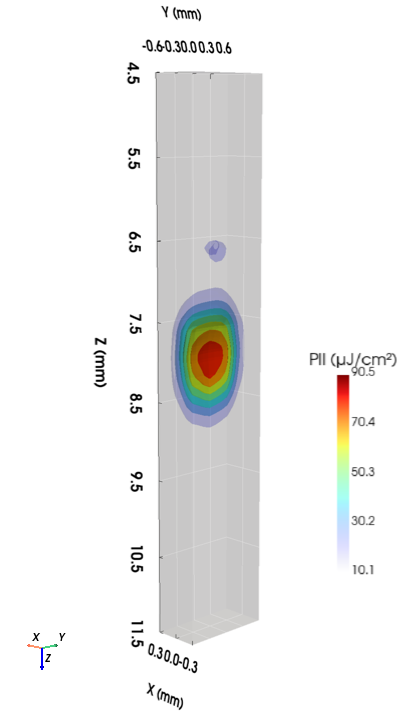

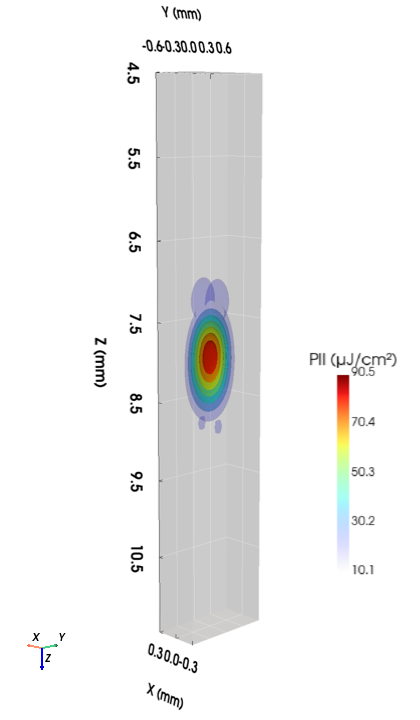

Plotting F/D = 1.5 : real and simulated


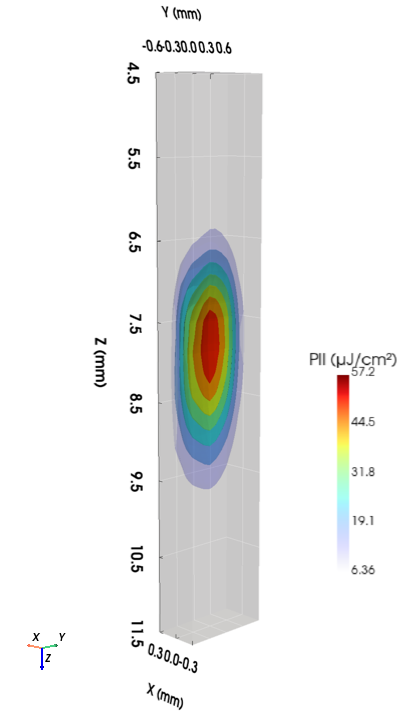

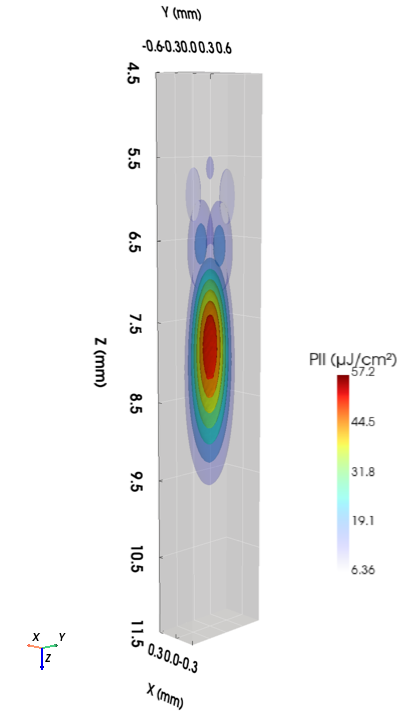

Plotting F/D = 2 : real and simulated


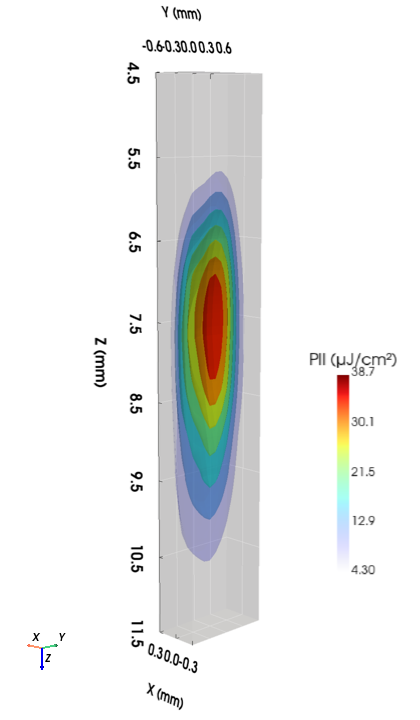

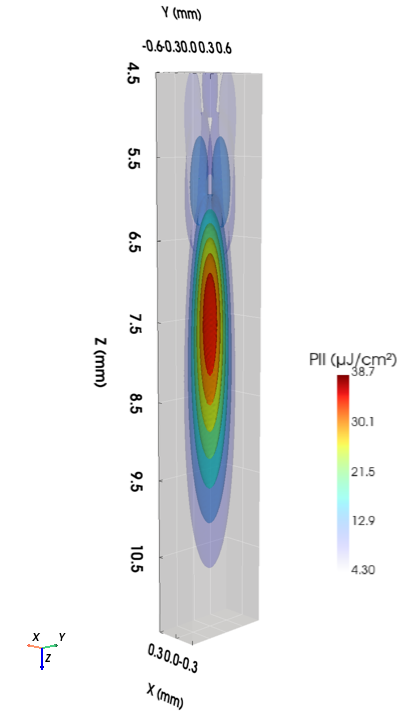

In [18]:
print('Plotting F/D = 1 : real and simulated')
plot_volume(real_x1, real_y1, real_z1, real_FD1, image_name=folder+'FD1_real.png') #, image_name = 'FD1_real.png')
plot_volume(simu_x1, simu_y1, simu_z1, simu_FD1, image_name=folder+f'FD1_simu{method}.png') #, image_name = 'FD1_real.png')

print('Plotting F/D = 1.5 : real and simulated')
plot_volume(real_x15, real_y15, real_z15, real_FD15, image_name=folder+'FD15_real.png') #, image_name = 'FD1_real.png')
plot_volume(simu_x15, simu_y15, simu_z15, simu_FD15, image_name=folder+f'FD15_simu{method}.png') #, image_name = 'FD1_real.png')

print('Plotting F/D = 2 : real and simulated')
plot_volume(real_x2, real_y2, real_z2, real_FD2, image_name=folder+'FD2_real.png') #, image_name = 'FD1_real.png')
plot_volume(simu_x2, simu_y2, simu_z2, simu_FD2, image_name=folder+f'FD2_simu{method}.png') #, image_name = 'FD1_real.png')

### 1.4. 2D Visualization of pressure field

In [19]:
import matplotlib.gridspec as gridspec

def plot_comparison_slices(x,y,z, field1, field2, *, figsize = (10,8), xslice = 0, yslice = 0, zslice = 8, interpolation = 'bilinear', cmap = 'jet'):
    
    slice_idx = np.argmin(np.abs(x - xslice))
    slice_idy = np.argmin(np.abs(y - yslice))
    slice_idz = np.argmin(np.abs(z - zslice))

    print(f"slice_idx: {slice_idx}, slice_idy: {slice_idy}, slice_idz: {slice_idz}")
    print(f"xslice (mm): {x[slice_idx]:.2f}, yslice (mm): {y[slice_idy]:.2f}, zslice (mm): {z[slice_idz]:.2f}")

    vmin = min(field1.min(), field2.min())
    vmax = max(field1.max(), field2.max())

    # Make a grid row 2 and 5 columns
    # first column plane xz field1
    # second column plane xz field2
    # first row third column plane yx field1
    # second row third column plane yx field2
    # fourth column plane zy field1
    # fifth column plane zy field2

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[0.5, 0.5, 1, 0.8, 0.8, 0.05])

    # a) XZ slices planes
    ax_xz_1 = fig.add_subplot(gs[:, 0])

    im = ax_xz_1.imshow(field1[:, slice_idy, :].T, extent=[x.min(), x.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_xz_1.set_xlabel('x (mm)')
    ax_xz_1.set_ylabel('z (mm)')
    ax_xz_1.set_xticks([x.min(), 0, x.max()])
    ax_xz_1.set_xticklabels([f"{x.min():.1f}", "0", f"{x.max():.1f}"])
    ax_xz_1.set_title('a)')
    
    ax_xz_2 = fig.add_subplot(gs[:, 1])
    ax_xz_2.imshow(field2[:, slice_idy, :].T, extent=[x.min(), x.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_xz_2.set_xlabel('x (mm)')
    ax_xz_2.set_ylabel('z (mm)')
    ax_xz_2.set_xticks([x.min(), 0, x.max()])
    ax_xz_2.set_xticklabels([f"{x.min():.1f}", "0", f"{x.max():.1f}"])
    ax_xz_2.set_title('b)')

    # b) YX slices planes
    ax_yx_1 = fig.add_subplot(gs[0, 2])
    im = ax_yx_1.imshow(field1[:, :, slice_idz].T, extent=[x.min(), x.max(), y.max(), y.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_yx_1.set_xlabel('x (mm)')
    ax_yx_1.set_ylabel('y (mm)')
    ax_yx_1.set_title('c)')

    ax_yx_2 = fig.add_subplot(gs[1, 2])
    ax_yx_2.imshow(field2[:, :, slice_idz].T, extent=[x.min(), x.max(), y.max(), y.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_yx_2.set_xlabel('x (mm)')
    ax_yx_2.set_ylabel('y (mm)')
    ax_yx_2.set_title('d)')

    # c) ZY slices planes
    ax_zy_1 = fig.add_subplot(gs[:, 3])
    im = ax_zy_1.imshow(field1[slice_idx, :, :].T, extent=[y.min(), y.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_zy_1.set_xlabel('y (mm)')
    ax_zy_1.set_ylabel('z (mm)')
    ax_zy_1.set_title('e)')
    
    ax_zy_2 = fig.add_subplot(gs[:, 4])
    ax_zy_2.imshow(field2[slice_idx, :, :].T, extent=[y.min(), y.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_zy_2.set_xlabel('y (mm)')
    ax_zy_2.set_ylabel('z (mm)')
    ax_zy_2.set_title('f)')

    # Add colorbar to the right of the last column
    # Make it span both rows
    cax = fig.add_subplot(gs[:, 5])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('PII₀ (μJ/cm²)')
    plt.tight_layout()
    return fig                     

def plot_comparison_contours(x, y, z, field1, field2, *, figsize=(10, 8), xslice=0, yslice=0, zslice=8, cmap='jet', levels=15):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import numpy as np

    slice_idx = np.argmin(np.abs(x - xslice))
    slice_idy = np.argmin(np.abs(y - yslice))
    slice_idz = np.argmin(np.abs(z - zslice))

    print(f"slice_idx: {slice_idx}, slice_idy: {slice_idy}, slice_idz: {slice_idz}")
    print(f"xslice (mm): {x[slice_idx]:.2f}, yslice (mm): {y[slice_idy]:.2f}, zslice (mm): {z[slice_idz]:.2f}")

    vmin = min(field1.min(), field2.min())
    vmax = max(field1.max(), field2.max())

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[0.5, 0.5, 1, 0.8, 0.8, 0.05])

    # a) XZ slices planes
    ax_xz_1 = fig.add_subplot(gs[:, 0])
    X, Z = np.meshgrid(x, z)
    cf1 = ax_xz_1.contourf(x, z, field1[:, slice_idy, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_xz_1.set_xlabel('x (mm)')
    ax_xz_1.set_ylabel('z (mm)')
    ax_xz_1.set_xticks([x.min(), 0, x.max()])
    ax_xz_1.set_xticklabels([f"{x.min():.2f}", "0", f"{x.max():.2f}"])
    ax_xz_1.invert_yaxis()
    ax_xz_1.set_title('a)')

    ax_xz_2 = fig.add_subplot(gs[:, 1])
    cf2 = ax_xz_2.contourf(x, z, field2[:, slice_idy, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_xz_2.set_xlabel('x (mm)')
    ax_xz_2.set_ylabel('z (mm)')
    ax_xz_2.set_xticks([x.min(), 0, x.max()])
    ax_xz_2.set_xticklabels([f"{x.min():.2f}", "0", f"{x.max():.2f}"])
    ax_xz_2.invert_yaxis()
    ax_xz_2.set_title('b)')

    # b) YX slices planes
    ax_yx_1 = fig.add_subplot(gs[0, 2])
    cf3 = ax_yx_1.contourf(x, y, field1[:, :, slice_idz].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_yx_1.set_xlabel('x (mm)')
    ax_yx_1.set_ylabel('y (mm)')
    ax_yx_1.invert_yaxis()
    ax_yx_1.set_title('c)')

    ax_yx_2 = fig.add_subplot(gs[1, 2])
    cf4 = ax_yx_2.contourf(x, y, field2[:, :, slice_idz].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_yx_2.set_xlabel('x (mm)')
    ax_yx_2.set_ylabel('y (mm)')
    ax_yx_2.invert_yaxis()
    ax_yx_2.set_title('d)')

    # c) ZY slices planes
    ax_zy_1 = fig.add_subplot(gs[:, 3])
    cf5 = ax_zy_1.contourf(y, z, field1[slice_idx, :, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_zy_1.set_xlabel('y (mm)')
    ax_zy_1.set_ylabel('z (mm)')
    ax_zy_1.invert_yaxis()
    ax_zy_1.set_title('e)')

    ax_zy_2 = fig.add_subplot(gs[:, 4])
    cf6 = ax_zy_2.contourf(y, z, field2[slice_idx, :, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_zy_2.set_xlabel('y (mm)')
    ax_zy_2.set_ylabel('z (mm)')
    ax_zy_2.invert_yaxis()
    ax_zy_2.set_title('f)')

    # Add colorbar to the right of the last column (use the last contourf for colorbar)
    cax = fig.add_subplot(gs[:, 5])
    cbar = fig.colorbar(cf6, cax=cax)
    cbar.set_label('PII₀ (μJ/cm²)')
    plt.tight_layout()
    return fig



slice_idx: 34, slice_idy: 64, slice_idz: 99
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.98
slice_idx: 34, slice_idy: 64, slice_idz: 119
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.99
slice_idx: 34, slice_idy: 64, slice_idz: 99
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.98


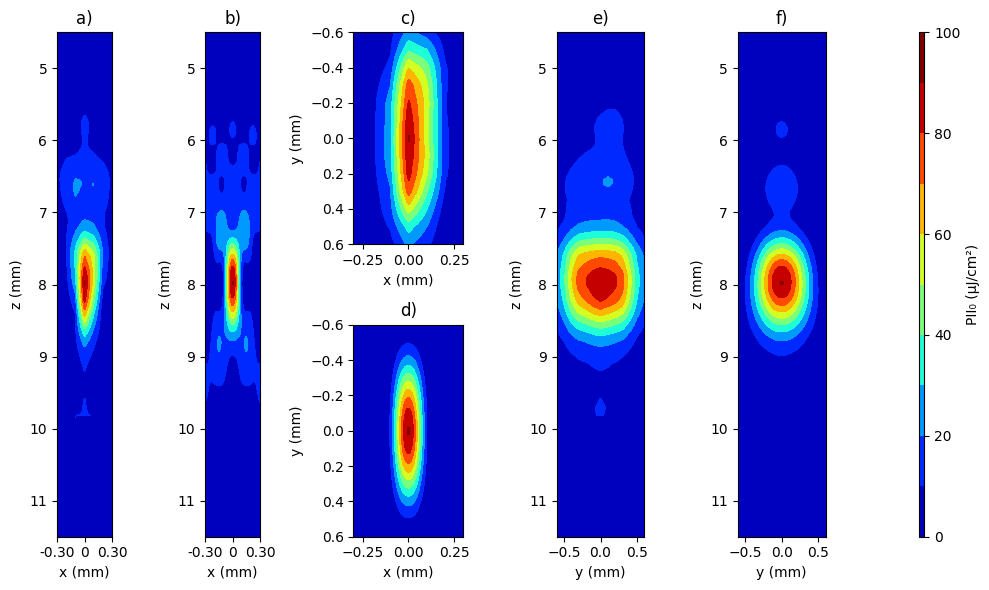

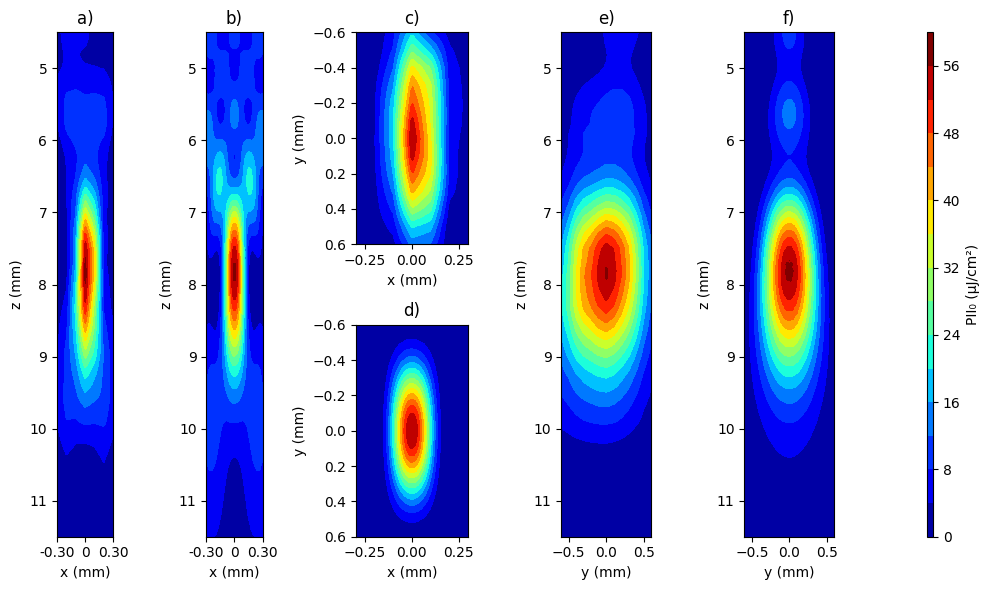

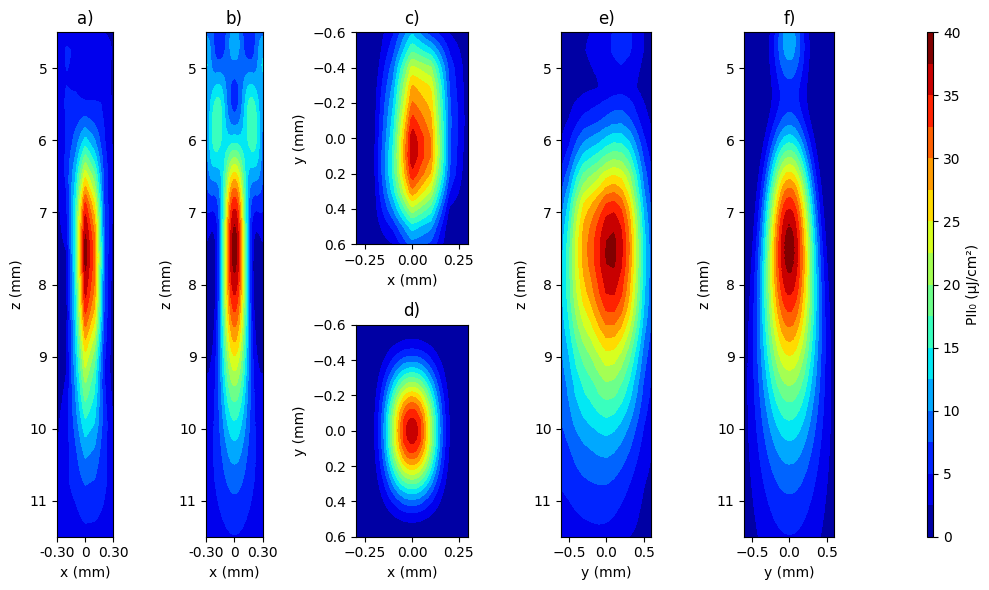

In [20]:
fig_cFD1 = plot_comparison_contours(real_x1, real_y1, real_z1, real_FD1, simu_FD1, figsize = (10,6), levels = 10)
fig_cFD15 = plot_comparison_contours(real_x15, real_y15, real_z15, real_FD15, simu_FD15, figsize = (10,6))
fig_cFD2 = plot_comparison_contours(real_x2, real_y2, real_z2, real_FD2, simu_FD2, figsize = (10,6))

slice_idx: 34, slice_idy: 64, slice_idz: 99
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.98
slice_idx: 34, slice_idy: 64, slice_idz: 119
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.99
slice_idx: 34, slice_idy: 64, slice_idz: 99
xslice (mm): -0.00, yslice (mm): -0.00, zslice (mm): 7.98


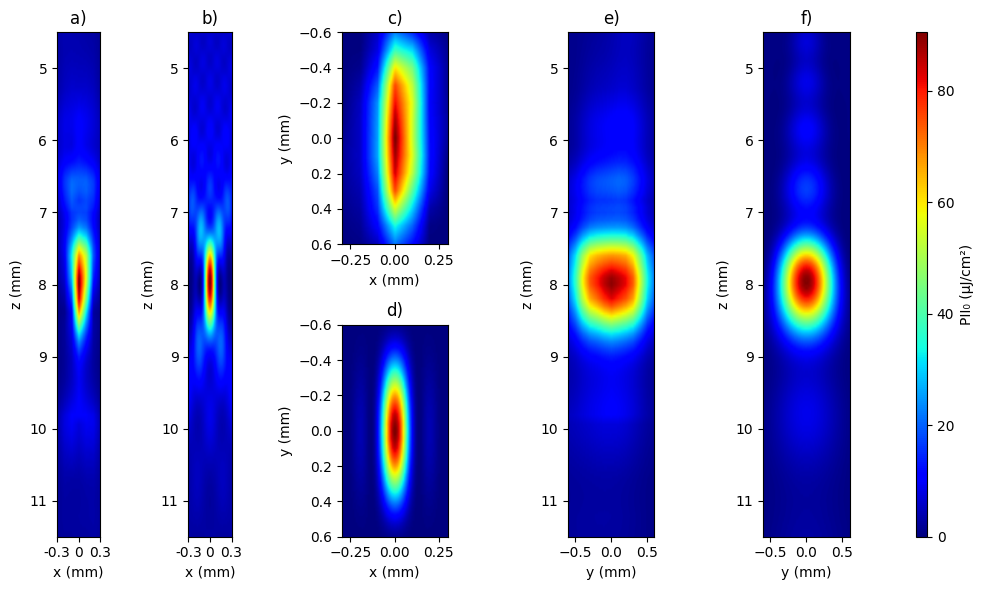

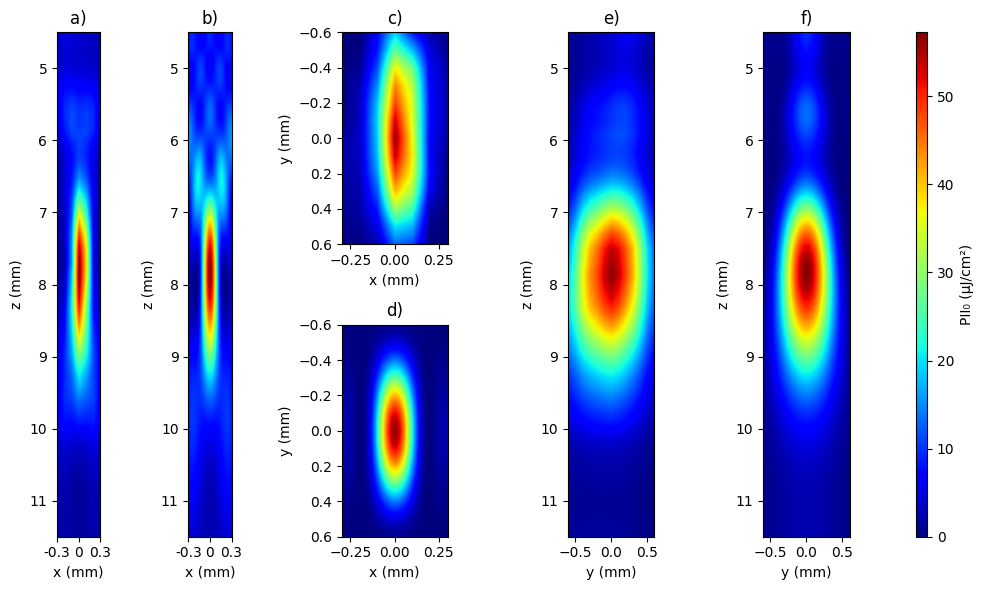

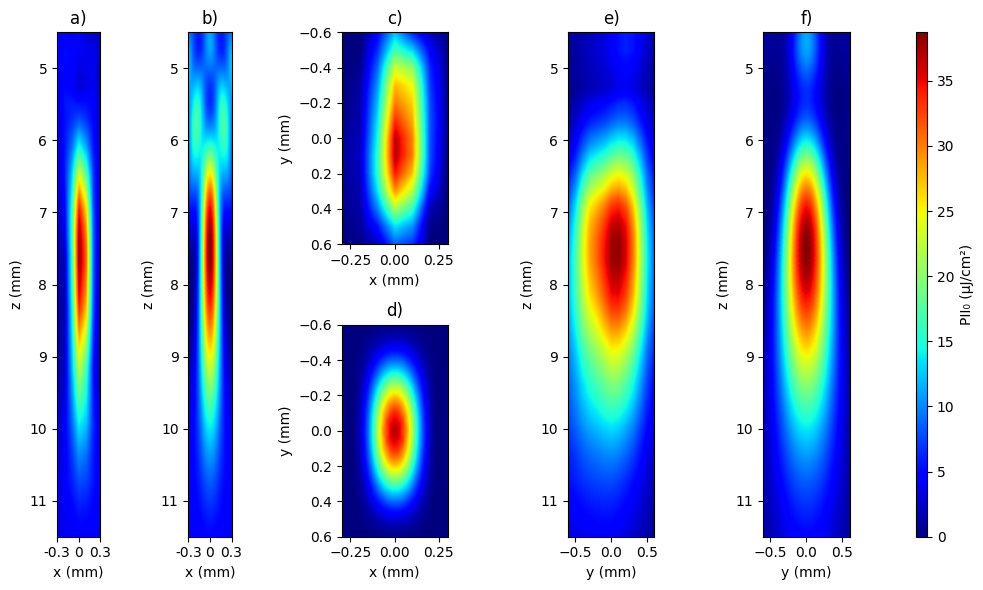

In [21]:
fig_FD1 = plot_comparison_slices(real_x1, real_y1, real_z1, real_FD1, simu_FD1, figsize = (10,6))
fig_FD15 = plot_comparison_slices(real_x15, real_y15, real_z15, real_FD15, simu_FD15, figsize = (10,6))
fig_FD2 = plot_comparison_slices(real_x2, real_y2, real_z2, real_FD2, simu_FD2, figsize = (10,6))

In [22]:
# fig_FD1.savefig(folder+f'Comparison_FD1{method}.png', dpi=300)
# fig_FD15.savefig(folder+f'Comparison_FD15{method}.png', dpi=300)
# fig_FD2.savefig(folder+f'Comparison_FD2{method}.png', dpi=300)
# fig_cFD1.savefig(folder+f'Comparison_contour_FD1{method}.png', dpi=300)
# fig_cFD15.savefig(folder+f'Comparison_contour_FD15{method}.png', dpi=300)
# fig_cFD2.savefig(folder+f'Comparison_contour_FD2{method}.png', dpi=300)

## 2. Simulations of stimulation

### 2.1. Preparation of stimulation grid

Create the focalization sites

In [87]:
x_focus = np.linspace(0, 10, 11)
z_focus = np.linspace(1, 16, 11)
y_focus = 0

print('scanned x positions: ', x_focus)
print('scanned z positions: ', z_focus)

FoverD = 2
apodization_type = 'rect'
method = 'auto'

# field properties
c = 1540 # m/s
alpha0 = 2.2e-3 # dB/(MHz^y cm)
freq_power = 2 

domino = transducers.Domino()

max_pressure = np.zeros((len(x_focus), len(z_focus)))
max_locations = np.zeros((len(x_focus), len(z_focus), 2))


scanned x positions:  [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
scanned z positions:  [ 1.   2.5  4.   5.5  7.   8.5 10.  11.5 13.  14.5 16. ]
LinearArrayTransducer initialized in 0.0180 seconds.


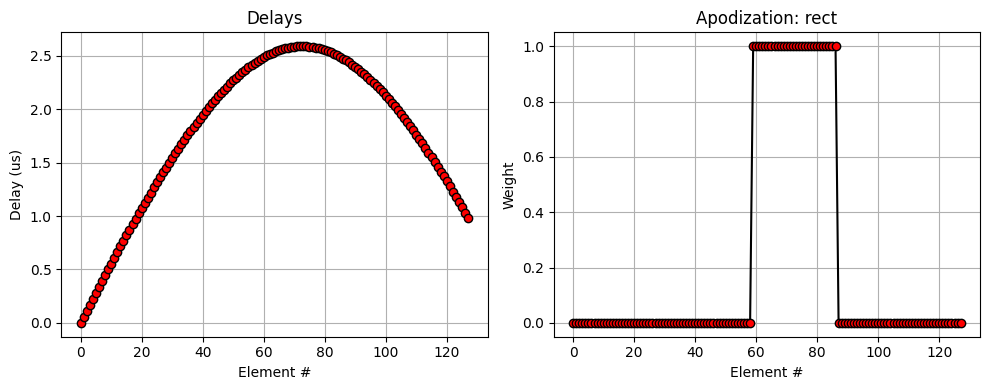

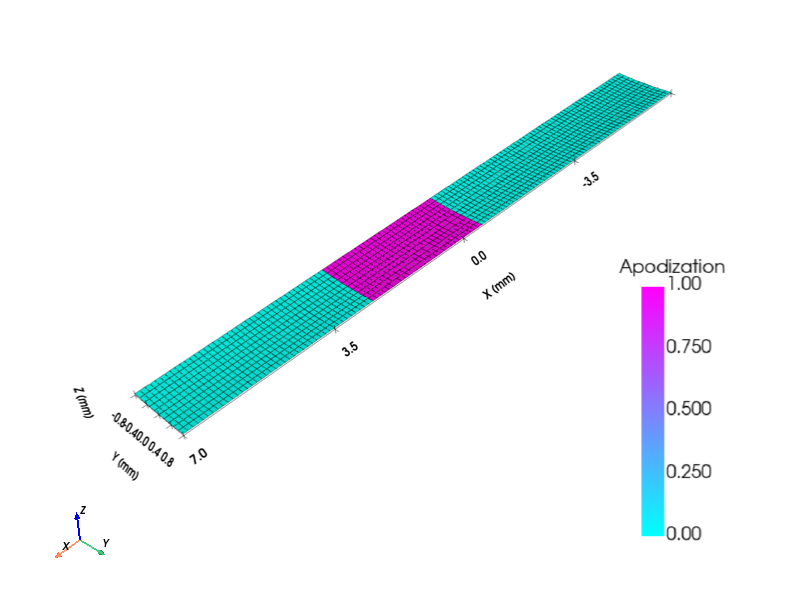

In [88]:
focus_mm = np.array([1, y_focus, 6])

delays = domino.compute_delays(focus_mm=focus_mm)
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type=apodization_type)
domino.plot_delays_apodization()
domino.show(notebook=True, jupyter_backend='static')

field_info_mm = {
"x_extent" : [-2+focus_mm[0], 2+focus_mm[0]],
"y_extent" : [-0.1+focus_mm[1], 0.1+focus_mm[1]],
"z_extent" : [-3+focus_mm[2], 3+focus_mm[2]],
"dx" : 0.05,
"dy" : 0.05,
"dz" : 0.05,
}


In [89]:
domino_field = PyField(domino, c=c, alpha0=alpha0, freq_power=freq_power)
x, y, z, pressure = domino_field(field_info_mm, method = method)

Computing SIR for 49005 points and 1280 patches...
Computed time grid from 1.86 us to 11.40 us, with 1909 samples in 0.01 seconds.
Transducer SIR computed in 0.48 seconds...
Pressure computed from SIR in 0.69 seconds...
Pressure field computed in 1.33 seconds...


Taking slice (1.0,0.0,6.0) => x_ind, y_ind, z_ind = 41/81, 3/5, 61/121


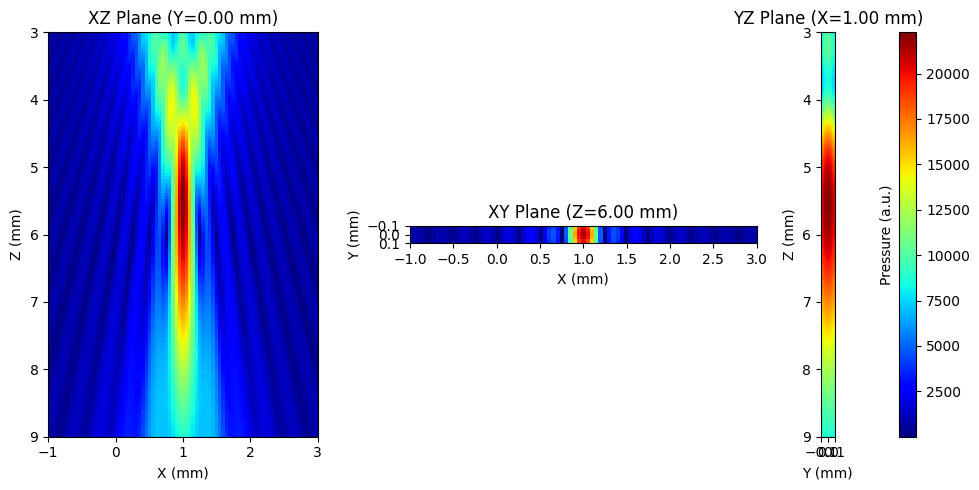

In [90]:
ratios = [1,1,0.1]
pysonogen.plot_field_planes(pressure,x,y,z, centered_to_max=False, ratios=ratios)

### 2.2. Loop over stimulation grid

In [91]:
def plot_plane(x, z, plane, *, xlabel='x (mm)', ylabel='z (mm)', title='', figsize=(6,5), cmap='jet', interpolation=None):
    plt.figure(figsize=figsize)
    plt.imshow(plane.T, extent=[x.min(), x.max(), z.max(), z.min()], aspect='equal', cmap=cmap, interpolation=interpolation)
    plt.colorbar(label='Pressure (a.u.)')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)    
    plt.title(title)
    plt.show()
    return

In [92]:
planes = np.zeros((len(x), len(z), len(x_focus), len(z_focus[z_focus>5])), dtype=bool)
Delta_z = 3

In [ ]:
counter = 0
for z_i, zf in enumerate(z_focus):
    if zf > 5:
        counter += 1
    for x_i, xf in enumerate(x_focus):
        focus_mm = np.array([xf, y_focus, zf])
        print(f'Computing focus at: {focus_mm} mm')
        delays = domino.compute_delays(focus_mm=focus_mm)
        apodization = domino.compute_apodization( 
            focus_mm=focus_mm, FoverD=FoverD, apodization_type=apodization_type)
        
        # shift a lil
        x_shift_simu = 0
        z_shift_simu = 0
        if xf >= 7 and zf > 5 :
            z_shift_simu += -2

        if xf > 8.5 :
            x_shift_simu += -1

        field_info_mm = {
        "x_extent" : [-2+focus_mm[0]+x_shift_simu, 2+focus_mm[0]+x_shift_simu],
        "y_extent" : [-0.05+focus_mm[1], 0.05+focus_mm[1]],
        "z_extent" : [-Delta_z+focus_mm[2]+z_shift_simu, Delta_z+focus_mm[2]+z_shift_simu],
        "dx" : 0.05,
        "dy" : 0.05,
        "dz" : 0.05,
        }

        domino_field = PyField(domino)
        x, y, z, pressure = domino_field(field_info_mm, method = method)

        print(f"pressure field shape:{pressure.shape}")
        # ind_y = len(y)//2
        plane_xz = np.mean(pressure, axis=1)

        # save mask x-z plane at y = 0 of pr > 0.5*max(pressure)
        if zf > 5:
            planes[:, :, x_i, counter-1] = plane_xz

        max_pressure[x_i, z_i] = np.max(pressure)
        x_max, y_max, z_max =  np.unravel_index(np.argmax(pressure), pressure.shape)
        max_locations[x_i, z_i,0] = x[x_max]
        max_locations[x_i, z_i,1] = z[z_max]
        print(f'Max pressure at: {max_locations[x_i, z_i]} mm')
        
        # pysonogen.plot_field_planes(pressure,x,y,z, ratios=ratios)
        plot_plane(x, z, plane_xz) # title='x-z plane at y=0 mm')


Computing focus at: [0. 0. 1.] mm
Computing SIR for 19197 points and 1280 patches...
Computed time grid from 0.00 us to 10.41 us, with 2083 samples in 0.01 seconds.
Transducer SIR computed in 0.07 seconds...


## 2.3. Analyse stimulation grid

In [ ]:

x_expected_focus = np.zeros((len(x_focus),len(z_focus),1))
x_real_focus = np.zeros((len(x_focus),len(z_focus),1))
z_expected_focus = np.zeros((len(x_focus),len(z_focus),1))
z_real_focus = np.zeros((len(x_focus),len(z_focus),1))
for x_i, xf in enumerate(x_focus):
    for z_i, zf in enumerate(z_focus):
        x_expected_focus[x_i, z_i] = xf
        x_real_focus[x_i, z_i] = max_locations[x_i, z_i,0]
        z_expected_focus[x_i, z_i] = zf
        z_real_focus[x_i, z_i] = max_locations[x_i, z_i,1]
        

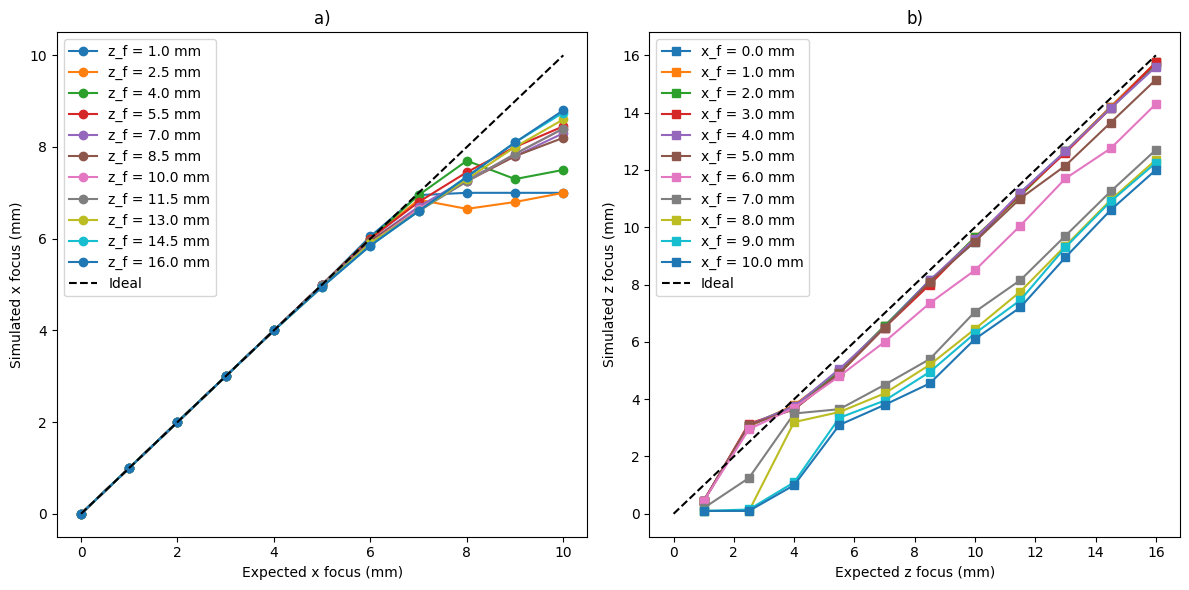

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,6))

for i in range(len(z_focus)):
    ax[0].plot(x_expected_focus[:, i], x_real_focus[:, i], 'o-', label = f'z_f = {z_focus[i]} mm')

ax[0].plot([0, 10], [0, 10], 'k--', label = 'Ideal')
ax[0].set_xlabel('Expected x focus (mm)')
ax[0].set_ylabel('Simulated x focus (mm)')
ax[0].set_title('a)')
ax[0].legend()

for i in range(len(x_focus)):
    ax[1].plot(z_expected_focus[i, :], z_real_focus[i, :], 's-', label = f'x_f = {x_focus[i]} mm')
ax[1].plot([0, 16], [0, 16], 'k--', label = 'Ideal')
ax[1].set_xlabel('Expected z focus (mm)')
ax[1].set_ylabel('Simulated z focus (mm)')
ax[1].set_title('b)')
ax[1].legend()
plt.tight_layout()

plt.show()

In [ ]:
from scipy.interpolate import griddata

# Original grid
X, Z = np.meshgrid(x_focus, z_focus)
points = np.array([X.flatten(), Z.flatten()]).T
values = max_pressure.T.flatten()/np.max(max_pressure)

# Create a finer grid
x_fine = np.linspace(x_focus.min(), x_focus.max(), 100)
z_fine = np.linspace(z_focus.min(), z_focus.max(), 100)
X_fine, Z_fine = np.meshgrid(x_fine, z_fine)

# Interpolate
max_pressure_fine = griddata(points, values, (X_fine, Z_fine), method='cubic')

# Plot
plt.contourf(x_fine, z_fine, max_pressure_fine, levels=15, cmap='jet', vmin=0, vmax=1)
plt.scatter(max_locations[:, :, 0], max_locations[:, :, 1], c='white', edgecolors='black', label='Max Locations')
plt.scatter(points[:,0], points[:,1], c='gray', edgecolors='black', label='Focus Locations')
plt.xlabel('x focus (mm)')
plt.ylabel('z focus (mm)')
plt.gca().invert_yaxis()  # Flip y-axis
plt.title('Smoothed Pressure Contours')
plt.colorbar(label='Pressure')
plt.grid()
plt.show()

ValueError: different number of values and points

In [ ]:
points

array([[ 0. ,  1. ],
       [ 1. ,  1. ],
       [ 2. ,  1. ],
       [ 3. ,  1. ],
       [ 4. ,  1. ],
       [ 5. ,  1. ],
       [ 6. ,  1. ],
       [ 7. ,  1. ],
       [ 8. ,  1. ],
       [ 9. ,  1. ],
       [10. ,  1. ],
       [ 0. ,  2.5],
       [ 1. ,  2.5],
       [ 2. ,  2.5],
       [ 3. ,  2.5],
       [ 4. ,  2.5],
       [ 5. ,  2.5],
       [ 6. ,  2.5],
       [ 7. ,  2.5],
       [ 8. ,  2.5],
       [ 9. ,  2.5],
       [10. ,  2.5],
       [ 0. ,  4. ],
       [ 1. ,  4. ],
       [ 2. ,  4. ],
       [ 3. ,  4. ],
       [ 4. ,  4. ],
       [ 5. ,  4. ],
       [ 6. ,  4. ],
       [ 7. ,  4. ],
       [ 8. ,  4. ],
       [ 9. ,  4. ],
       [10. ,  4. ],
       [ 0. ,  5.5],
       [ 1. ,  5.5],
       [ 2. ,  5.5],
       [ 3. ,  5.5],
       [ 4. ,  5.5],
       [ 5. ,  5.5],
       [ 6. ,  5.5],
       [ 7. ,  5.5],
       [ 8. ,  5.5],
       [ 9. ,  5.5],
       [10. ,  5.5],
       [ 0. ,  7. ],
       [ 1. ,  7. ],
       [ 2. ,  7. ],
       [ 3. ,